# DLinear - Walmart Weekly Sales

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore", category=UserWarning)

# Make the project root importable when running the notebook from notebooks/
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import wandb

# If your package isn't named "src", change the imports below.
from src.walmart_forecasting.data import load_processed_data
from src.walmart_forecasting.paths import TABLES_DIR
from src.walmart_forecasting.validation import chronological_holdout, expanding_window_splits
from src.walmart_forecasting.experiment import (
    HOLIDAY_WEIGHT,
    NON_HOLIDAY_WEIGHT,
    CV_FOLDS,
    CV_VALIDATION_WEEKS,
    FINAL_HOLDOUT_WEEKS,
    DEFAULT_RANDOM_SEED,
    build_common_parameters,
    build_result_row,
    make_run_name,
)
from src.walmart_forecasting.tracking import wandb_run

# Reproducibility. Note: neither CPU nor MPS kernels are bit-for-bit deterministic across
# machines, so expect tiny run-to-run drift in the metrics even with the seeds pinned.
np.random.seed(DEFAULT_RANDOM_SEED)
torch.manual_seed(DEFAULT_RANDOM_SEED)

# DLinear is two Linear layers. It is so small that per-kernel launch overhead dominates, and
# on Apple Silicon the CPU actually beats the MPS (Metal) backend here -- benchmarked at
# ~0.24 s/epoch on CPU vs ~0.53 s/epoch on MPS for the largest fold at batch 1024.
# Flip USE_MPS to True to compare for yourself. (This is also why a linear model is the wrong
# reason to reach for a Colab GPU.)
USE_MPS = False
DEVICE = (
    torch.device("mps")
    if USE_MPS and torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Setup complete. torch={torch.__version__}, device={DEVICE}, "
      f"mps_available={torch.backends.mps.is_available()}")

/Users/chkhai/Documents/uni6/ml/walmart-store-sales-forecasting/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete. torch=2.13.0, device=cpu, mps_available=True


## 0. Experiment configuration

In [2]:
ARCHITECTURE = "dlinear"
STAGE = "tuning"  # representative_series scope isn't a "final" leaderboard scope
FORECAST_STRATEGY = "global_channel_independent"  # one shared model over all series
EVALUATION_SCOPE = "representative_series"  # metrics pooled over the shared 30
EXPERIMENT_NAME = "DLinear_Training"  # used as the W&B run *group* (one group per architecture)
JOB_TYPE_CV = "cv"        # one run per trial, opened *before* training so curves + runtime land
JOB_TYPE_FINAL = "final"  # the winner's single holdout evaluation

RESULTS_FILENAME = "dlinear_representative_results.csv"  # not "_final" -- representative scope only
SERIES_PATH = TABLES_DIR / "representative_series_v1.csv"  # shared with ARIMA / SARIMA / Prophet

# DLinear-only training hyperparameters (shared across trials unless a trial overrides them).
# A learning-rate sweep (1e-2 / 1e-3 / 5e-4) moved CV WMAE by less than the run-to-run seed
# noise, so 1e-2 is kept: it simply converges fastest. Early stopping reaches the same accuracy
# in 10-20 epochs instead of a fixed 80, roughly a 5x speedup.
LEARNING_RATE = 1e-2
MAX_EPOCHS = 100
PATIENCE = 5           # stop after this many epochs without validation improvement
VAL_FRACTION = 0.1     # share of *training windows* held out to decide when to stop
BATCH_SIZE = 1024      # large batches: the model is tiny, so per-step overhead dominates
MIN_TRAIN_WEEKS = 65   # a series must be long enough to form at least one 52+13 window

## 1. Load processed data, the shared representative series, and the global training pool

In [3]:
processed = load_processed_data()
merged_train = processed.train.copy()
merged_train["Date"] = pd.to_datetime(merged_train["Date"])
merged_train = merged_train.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

if not SERIES_PATH.exists():
    raise FileNotFoundError(
        f"{SERIES_PATH} not found -- run the Prophet notebook first (or any notebook using "
        "RepresentativeSeriesSelector.select_and_save), it builds this shared 30-series file."
    )

selected = pd.read_csv(SERIES_PATH)
selected_keys = list(zip(selected["Store"], selected["Dept"]))

print(f"Train rows (all): {len(merged_train):,}")
print(f"Representative (scoring) series: {len(selected_keys)}")
selected[["Store", "Dept", "total_sales", "n_weeks", "volume_tier"]]

Train rows (all): 421,570
Representative (scoring) series: 30


,Store,Dept,total_sales,n_weeks,volume_tier
0,15,52,223257.76,143,low
1,35,83,357099.15,143,low
2,28,52,378310.35,143,low
3,33,74,51952.16,143,low
4,32,52,359356.63,143,low
5,3,21,177967.74,143,low
6,28,31,369504.14,143,low
7,30,98,458605.96,143,low
8,37,87,145869.61,143,low
9,7,31,257336.97,143,low


In [4]:
def is_gap_free(dates: pd.Series) -> bool:
    """True if consecutive observations are exactly 7 days apart throughout."""
    deltas = dates.diff().dropna().dt.days
    return bool((deltas == 7).all())


series_calendar = merged_train.groupby(["Store", "Dept"])["Date"]
clean_keys = {
    key for key, dates in series_calendar
    if len(dates) >= MIN_TRAIN_WEEKS and is_gap_free(dates.sort_values())
}

missing_reps = set(selected_keys) - clean_keys
if missing_reps:
    raise RuntimeError(
        f"Representative series excluded from the training pool: {sorted(missing_reps)}"
    )

clean_frame = pd.DataFrame(sorted(clean_keys), columns=["Store", "Dept"])
pool_df = merged_train.merge(clean_frame, on=["Store", "Dept"], how="inner")
pool_df = pool_df.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

rep_df = merged_train.merge(
    selected[["Store", "Dept"]], on=["Store", "Dept"], how="inner"
).sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

print(f"Training pool: {len(clean_keys):,} gap-free series "
      f"({merged_train.groupby(['Store', 'Dept']).ngroups - len(clean_keys):,} excluded), "
      f"{len(pool_df):,} rows")
print(f"Scoring set:   {len(selected_keys)} representative series, {len(rep_df):,} rows")
print("All 30 representative series are inside the training pool.")

Training pool: 2,672 gap-free series (659 excluded), 381,902 rows
Scoring set:   30 representative series, 4,290 rows
All 30 representative series are inside the training pool.


## 2. Weighted MAE (pooled)

In [5]:
def weighted_mae(y_true, y_pred, is_holiday):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weights = np.where(np.asarray(is_holiday, dtype=bool), HOLIDAY_WEIGHT, NON_HOLIDAY_WEIGHT)
    return float(np.average(np.abs(y_true - y_pred), weights=weights))

## 3. The DLinear model (+ RevIN, + optional covariate head)

In [6]:
class MovingAvg(nn.Module):
    """Length-preserving moving average that isolates the trend component."""

    def __init__(self, kernel_size: int):
        super().__init__()
        if kernel_size % 2 == 0:
            raise ValueError("kernel_size must be odd so endpoint padding stays symmetric.")
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=0)

    def forward(self, x):  # x: [B, L, C]
        pad = (self.kernel_size - 1) // 2
        front = x[:, :1, :].repeat(1, pad, 1)
        end = x[:, -1:, :].repeat(1, pad, 1)
        x_padded = torch.cat([front, x, end], dim=1)
        return self.avg(x_padded.permute(0, 2, 1)).permute(0, 2, 1)


class SeriesDecomp(nn.Module):
    def __init__(self, kernel_size: int):
        super().__init__()
        self.moving_avg = MovingAvg(kernel_size)

    def forward(self, x):  # x: [B, L, C]
        trend = self.moving_avg(x)
        return x - trend, trend


class CovariateHead(nn.Module):
    """Additive head over known-future covariates. Zero-init => starts as a no-op."""

    def __init__(self, cov_dim: int, horizon: int):
        super().__init__()
        self.linear = nn.Linear(cov_dim, horizon)
        nn.init.zeros_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, cov):  # cov: [B, cov_dim] -> [B, H, 1]
        return self.linear(cov).unsqueeze(-1)


class DLinear(nn.Module):
    def __init__(self, lookback: int, horizon: int, kernel_size: int = 25, cov_dim: int = 0):
        super().__init__()
        self.decomp = SeriesDecomp(kernel_size)
        # Channel-independent / weight-shared: a single linear map reused for every series.
        self.linear_seasonal = nn.Linear(lookback, horizon)
        self.linear_trend = nn.Linear(lookback, horizon)
        self.cov_head = CovariateHead(cov_dim, horizon) if cov_dim else None

    def forward(self, x, cov=None):  # x: [B, L, C]
        seasonal, trend = self.decomp(x)
        seasonal = seasonal.permute(0, 2, 1)  # [B, C, L]
        trend = trend.permute(0, 2, 1)
        out = (self.linear_seasonal(seasonal) + self.linear_trend(trend)).permute(0, 2, 1)
        if self.cov_head is not None and cov is not None:
            out = out + self.cov_head(cov)
        return out  # [B, H, C]


class NLinear(nn.Module):
    def __init__(self, lookback: int, horizon: int, kernel_size: int = 25, cov_dim: int = 0):
        super().__init__()  # kernel_size accepted for a uniform constructor signature
        self.linear = nn.Linear(lookback, horizon)
        self.cov_head = CovariateHead(cov_dim, horizon) if cov_dim else None

    def forward(self, x, cov=None):  # x: [B, L, C]
        last = x[:, -1:, :]
        out = self.linear((x - last).permute(0, 2, 1)).permute(0, 2, 1) + last
        if self.cov_head is not None and cov is not None:
            out = out + self.cov_head(cov)
        return out


class RevIN(nn.Module):
    """Reversible instance normalization: strip each window's own level/scale, restore after."""

    def __init__(self, core: nn.Module):
        super().__init__()
        self.core = core

    def forward(self, x, cov=None):
        mean = x.mean(dim=1, keepdim=True)
        std = x.std(dim=1, keepdim=True) + 1e-5
        return self.core((x - mean) / std, cov) * std + mean


CORES = {"dlinear": DLinear, "nlinear": NLinear}


def build_model(model_name, lookback, horizon, kernel_size, use_revin, cov_dim):
    core = CORES[model_name](lookback, horizon, kernel_size, cov_dim)
    return RevIN(core) if use_revin else core

## 4. Per-series standardization, sliding windows, and loss weights

In [7]:
def series_frames(df):
    """Split a pooled DataFrame into per-(Store, Dept) date-sorted frames."""
    return {key: g.sort_values("Date") for key, g in df.groupby(["Store", "Dept"])}


def fit_series_stats(train_frames):
    """Mean/std per series from its training portion (std floored to avoid divide-by-zero)."""
    stats = {}
    for key, g in train_frames.items():
        values = g["Weekly_Sales"].to_numpy(dtype=float)
        std = float(values.std())
        stats[key] = (float(values.mean()), std if std > 1e-8 else 1.0)
    return stats


def week_of_year_features(dates):
    """sin/cos encoding of ISO week -- only ever used for *known future* dates."""
    week = pd.DatetimeIndex(dates).isocalendar().week.to_numpy().astype(float)
    return np.sin(2 * np.pi * week / 52.0), np.cos(2 * np.pi * week / 52.0)


def build_covariates(dates, is_holiday):
    """[IsHoliday, sin(week), cos(week)] flattened -> length 3*H."""
    sin_w, cos_w = week_of_year_features(dates)
    return np.concatenate([np.asarray(is_holiday, dtype=np.float32), sin_w, cos_w])


def build_windows(train_frames, stats, lookback, horizon, use_covariates):
    """Sliding windows over each standardized series, pooled across the whole training pool."""
    xs, ys, holiday_masks, scales, covariates = [], [], [], [], []
    for key, g in train_frames.items():
        mean, std = stats[key]
        values = (g["Weekly_Sales"].to_numpy(dtype=float) - mean) / std
        holidays = g["IsHoliday"].to_numpy(dtype=bool)
        dates = g["Date"].to_numpy()
        for start in range(0, len(values) - lookback - horizon + 1):
            mid, end = start + lookback, start + lookback + horizon
            xs.append(values[start:mid])
            ys.append(values[mid:end])
            holiday_masks.append(holidays[mid:end])
            scales.append(std)
            if use_covariates:
                covariates.append(build_covariates(dates[mid:end], holidays[mid:end]))

    if not xs:
        raise RuntimeError(f"No training windows for lookback={lookback}, horizon={horizon}.")

    x = np.asarray(xs, dtype=np.float32)[:, :, None]   # [N, L, 1]
    y = np.asarray(ys, dtype=np.float32)[:, :, None]   # [N, H, 1]
    holiday = np.asarray(holiday_masks, dtype=bool)    # [N, H]
    scale = np.asarray(scales, dtype=np.float32)       # [N]
    cov = (np.asarray(covariates, dtype=np.float32)
           if use_covariates else np.zeros((len(xs), 0), dtype=np.float32))
    return x, y, holiday, scale, cov


def loss_weights(holiday, scale, metric_aligned):
    """Per-element L1 weights. metric_aligned=False reproduces a plain unweighted L1."""
    if not metric_aligned:
        return np.ones(holiday.shape, dtype=np.float32)
    weights = np.where(holiday, HOLIDAY_WEIGHT, NON_HOLIDAY_WEIGHT).astype(np.float32)
    return weights * scale[:, None]  # dollar-scale x holiday emphasis

## 5. Train / predict helpers

In [8]:
def train_model(model, x, y, weights, cov, lr, max_epochs, patience,
                batch_size, device, val_fraction=VAL_FRACTION, on_epoch=None):
    """Adam + weighted L1, early-stopped on a held-out slice of the training windows.

    on_epoch(epoch, train_loss, val_loss) is called after every epoch, which is how the
    per-epoch curves reach W&B *while the run is still open*.
    """
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    use_cov = cov.shape[1] > 0

    indices = np.random.default_rng(DEFAULT_RANDOM_SEED).permutation(len(x))
    n_val = int(len(x) * val_fraction)
    use_early_stopping = patience is not None and n_val >= 1
    val_idx, train_idx = (indices[:n_val], indices[n_val:]) if use_early_stopping else (None, indices)

    loader = DataLoader(
        TensorDataset(*(torch.from_numpy(a[train_idx]) for a in (x, y, weights, cov))),
        batch_size=batch_size, shuffle=True,
    )
    if use_early_stopping:
        xv, yv, wv = (torch.from_numpy(a[val_idx]).to(device) for a in (x, y, weights))
        cv_ = torch.from_numpy(cov[val_idx]).to(device) if use_cov else None

    best_loss, best_state, epochs_without_gain, epochs_used = float("inf"), None, 0, 0

    for epoch in range(max_epochs):
        model.train()
        batch_loss_sum, batch_weight_sum = 0.0, 0.0
        for xb, yb, wb, cb in loader:
            xb, yb, wb = xb.to(device), yb.to(device), wb.to(device)
            cb = cb.to(device) if use_cov else None
            optimizer.zero_grad()
            errors = (model(xb, cb) - yb).abs().squeeze(-1)  # [B, H]
            weight_total = wb.sum()
            loss = (wb * errors).sum() / weight_total
            loss.backward()
            optimizer.step()
            batch_loss_sum += float(loss) * float(weight_total)
            batch_weight_sum += float(weight_total)
        epochs_used = epoch + 1
        train_loss = batch_loss_sum / batch_weight_sum

        val_loss = None
        if use_early_stopping:
            model.eval()
            with torch.no_grad():
                errors = (model(xv, cv_) - yv).abs().squeeze(-1)
                val_loss = float((wv * errors).sum() / wv.sum())

        if on_epoch is not None:
            on_epoch(epochs_used, train_loss, val_loss)

        if not use_early_stopping:
            continue

        if val_loss < best_loss - 1e-6:
            best_loss, epochs_without_gain = val_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_gain += 1
            if epochs_without_gain >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)  # restore the best weights, not the last ones
    return model, epochs_used


@torch.no_grad()
def predict_block(model, train_frames, val_frames, stats, lookback, use_covariates, device):
    """One horizon-length forecast per series, from that series' most recent lookback weeks."""
    model.eval()
    preds = {}
    for key, g in train_frames.items():
        if key not in val_frames:
            continue
        mean, std = stats[key]
        values = (g["Weekly_Sales"].to_numpy(dtype=float) - mean) / std
        if len(values) < lookback:
            continue  # not enough history to form an input window
        window = values[-lookback:][None, :, None].astype(np.float32)
        x = torch.from_numpy(window).to(device)

        cov = None
        if use_covariates:
            future = val_frames[key]
            block = build_covariates(future["Date"].to_numpy(),
                                     future["IsHoliday"].to_numpy(dtype=bool))
            cov = torch.from_numpy(block[None, :].astype(np.float32)).to(device)

        out = model(x, cov).cpu().numpy().reshape(-1)  # [H]
        preds[key] = out * std + mean  # invert standardization
    return preds

## 6. Shared date-partitioned splits (global model)

In [9]:
holdout_split = chronological_holdout(pool_df, validation_weeks=FINAL_HOLDOUT_WEEKS)
cv_splits = expanding_window_splits(
    holdout_split.train, n_splits=CV_FOLDS, validation_weeks=CV_VALIDATION_WEEKS
)

print(f"Holdout: {holdout_split.validation_start.date()} -> {holdout_split.validation_end.date()} "
      f"({holdout_split.validation_weeks} weeks)")
for i, fold in enumerate(cv_splits):
    weeks = int(fold.train.groupby(["Store", "Dept"]).size().median())
    print(f"  CV fold {i}: ~{weeks} train weeks/series, "
          f"val {fold.validation_start.date()} -> {fold.validation_end.date()}")

Holdout: 2012-02-03 -> 2012-10-26 (39 weeks)
  CV fold 0: ~65 train weeks/series, val 2011-05-06 -> 2011-07-29
  CV fold 1: ~78 train weeks/series, val 2011-08-05 -> 2011-10-28
  CV fold 2: ~91 train weeks/series, val 2011-11-04 -> 2012-01-27


## 7. Shared feature-set / preprocessing IDs

In [10]:
BASE_FEATURE_SET = "target_only_v1"        # past sales only
COV_FEATURE_SET = "target_calendar_v1"     # + known-future holiday / week-of-year

PLAIN_PREPROCESSING = "per_series_zscore_windows_v1"
REVIN_PREPROCESSING = "per_series_zscore_revin_windows_v1"

## 8. Trial runner

In [11]:
def _pool_predictions(pred_by_series, val_frames):
    rows = []
    for key, val in val_frames.items():
        if key not in pred_by_series:
            continue
        actual = val["Weekly_Sales"].to_numpy(dtype=float)
        rows.append(pd.DataFrame({
            "Store": key[0], "Dept": key[1], "Date": val["Date"].to_numpy(),
            "actual": actual, "prediction": pred_by_series[key][:len(actual)],
            "IsHoliday": val["IsHoliday"].to_numpy(),
        }))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def _fit_predict_split(config, split, horizon, eval_keys, on_epoch=None):
    """Fit on every pooled series in split.train; score only eval_keys on split.validation."""
    train_frames = series_frames(split.train)
    stats = fit_series_stats(train_frames)
    x, y, holiday, scale, cov = build_windows(
        train_frames, stats, config["lookback"], horizon, config["covariates"]
    )
    weights = loss_weights(holiday, scale, config["metric_aligned_loss"])

    torch.manual_seed(DEFAULT_RANDOM_SEED)
    model = build_model(
        config["model_name"], config["lookback"], horizon,
        config["kernel_size"], config["revin"], cov.shape[1],
    )
    # Note: this scales with the horizon (two Linear(L -> H) maps), so the 39-week holdout model
    # has ~3x the parameters of the 13-week CV model. Logged per-run, not as a single constant.
    parameter_count = sum(p.numel() for p in model.parameters())

    fit_start = time.perf_counter()
    model, epochs_used = train_model(
        model, x, y, weights, cov, LEARNING_RATE, MAX_EPOCHS, PATIENCE, BATCH_SIZE, DEVICE,
        on_epoch=on_epoch,
    )
    fit_seconds = time.perf_counter() - fit_start

    eval_set = set(eval_keys)
    val_frames = {k: g for k, g in series_frames(split.validation).items() if k in eval_set}
    eval_train_frames = {k: train_frames[k] for k in eval_keys if k in train_frames}

    predict_start = time.perf_counter()
    pred_by_series = predict_block(
        model, eval_train_frames, val_frames, stats,
        config["lookback"], config["covariates"], DEVICE,
    )
    predict_seconds = time.perf_counter() - predict_start

    pooled = _pool_predictions(pred_by_series, val_frames)
    return pooled, fit_seconds, predict_seconds, len(x), epochs_used, parameter_count


def _epoch_logger(wandb_handle, scope):
    """Stream per-epoch losses to an *open* W&B run. `scope` separates folds / holdout."""
    if wandb_handle is None:
        return None

    def log(epoch, train_loss, val_loss):
        payload = {"epoch": epoch, f"{scope}/train_loss": train_loss}
        if val_loss is not None:
            payload[f"{scope}/val_loss"] = val_loss
        wandb_handle.log(payload)

    return log


def run_dlinear_trial(config, do_cv=True, do_holdout=False, wandb_handle=None):
    eval_keys = selected_keys
    total_fit_seconds = total_predict_seconds = 0.0
    result = dict(config)
    result["series_count"] = len(eval_keys)

    if do_cv:
        fold_wmaes, fold_windows, fold_epochs = [], [], []
        for fold_index, fold in enumerate(cv_splits):
            pooled, fit_s, pred_s, n_windows, epochs_used, n_params = _fit_predict_split(
                config, fold, CV_VALIDATION_WEEKS, eval_keys,
                on_epoch=_epoch_logger(wandb_handle, f"fold{fold_index}"),
            )
            total_fit_seconds += fit_s
            total_predict_seconds += pred_s
            fold_windows.append(n_windows)
            fold_epochs.append(epochs_used)
            fold_wmaes.append(
                weighted_mae(pooled["actual"], pooled["prediction"], pooled["IsHoliday"])
            )
        result["cv_wmae_mean"] = float(np.mean(fold_wmaes))
        result["cv_wmae_std"] = float(np.std(fold_wmaes))
        result["fold_wmaes"] = fold_wmaes
        result["fold_windows"] = fold_windows
        result["fold_epochs"] = fold_epochs
        result["cv_parameter_count"] = n_params

    if do_holdout:
        pooled, fit_s, pred_s, n_windows, epochs_used, n_params = _fit_predict_split(
            config, holdout_split, FINAL_HOLDOUT_WEEKS, eval_keys,
            on_epoch=_epoch_logger(wandb_handle, "holdout"),
        )
        total_fit_seconds += fit_s
        total_predict_seconds += pred_s
        errors = pooled["actual"] - pooled["prediction"]
        result["holdout_wmae"] = weighted_mae(pooled["actual"], pooled["prediction"], pooled["IsHoliday"])
        result["holdout_mae"] = float(np.mean(np.abs(errors)))
        result["holdout_rmse"] = float(np.sqrt(np.mean(errors ** 2)))
        result["holdout_windows"] = n_windows
        result["final_epochs"] = epochs_used
        result["parameter_count"] = n_params
        result["pooled_holdout_predictions"] = pooled

    result["fit_seconds"] = total_fit_seconds
    result["predict_seconds"] = total_predict_seconds

    summary = []
    if do_cv:
        summary.append(f"cv_wmae_mean={result['cv_wmae_mean']:,.1f}")
        summary.append(f"cv_wmae_std={result['cv_wmae_std']:,.1f}")
        summary.append(f"epochs={result['fold_epochs']}")
    if do_holdout:
        summary.append(f"holdout_wmae={result['holdout_wmae']:,.1f}")
        summary.append(f"final_epochs={result['final_epochs']}")
        summary.append(f"params={result['parameter_count']:,}")
    print(f"[{config['label']}] " + ", ".join(summary) + f", fit={total_fit_seconds:.1f}s")
    return result

## 9. Trial configurations

In [12]:
def trial_config(label, model_name="dlinear", lookback=52, kernel_size=25,
                 revin=True, metric_aligned_loss=True, covariates=False,
                 eligible=True, feature_set=None, preprocessing=None):
    return {
        "label": label, "model_name": model_name, "lookback": lookback,
        "kernel_size": kernel_size, "revin": revin,
        "metric_aligned_loss": metric_aligned_loss, "covariates": covariates,
        "eligible": eligible,
        "feature_set": feature_set or (COV_FEATURE_SET if covariates else BASE_FEATURE_SET),
        "preprocessing": preprocessing or (REVIN_PREPROCESSING if revin else PLAIN_PREPROCESSING),
    }


TRIALS = [
    # A: the paper's vanilla recipe as we first implemented it -- the baseline to beat.
    trial_config("dlinear_plain", revin=False, metric_aligned_loss=False),
    # B: isolate RevIN.
    trial_config("dlinear_revin", revin=True, metric_aligned_loss=False),
    # C: RevIN + metric-aligned loss. Expected model of record.
    trial_config("dlinear_revin_weighted", revin=True, metric_aligned_loss=True),
    # D: shorter lookback -> far more training windows, but < 1 annual cycle of memory.
    trial_config("dlinear_revin_weighted_L26", lookback=26, kernel_size=13),
    # E: known-future covariates. Documented NEGATIVE result -- a shared seasonal head buys
    # nothing, because per-department seasonality cannot be expressed by one shared weight vector.
    trial_config("dlinear_revin_weighted_cov", covariates=True),
    # F: NLinear reference. Scored + logged, but not eligible as the DLinear model of record.
    trial_config("nlinear_weighted", model_name="nlinear", revin=False, eligible=False),
]

pd.DataFrame(TRIALS)[["label", "model_name", "lookback", "revin",
                      "metric_aligned_loss", "covariates", "eligible"]]

,label,model_name,lookback,revin,metric_aligned_loss,covariates,eligible
0,dlinear_plain,dlinear,52,False,False,False,True
1,dlinear_revin,dlinear,52,True,False,False,True
2,dlinear_revin_weighted,dlinear,52,True,True,False,True
3,dlinear_revin_weighted_L26,dlinear,26,True,True,False,True
4,dlinear_revin_weighted_cov,dlinear,52,True,True,True,True
5,nlinear_weighted,nlinear,52,False,True,False,False


## 10. Timing calibration -- run this before committing to the full loop

In [13]:
calib_config = trial_config("calibration")
calib_start = time.perf_counter()
_pooled, _fit_s, _pred_s, _n_windows, _epochs, _n_params = _fit_predict_split(
    calib_config, cv_splits[0], CV_VALIDATION_WEEKS, selected_keys
)
_calib_wmae = weighted_mae(_pooled["actual"], _pooled["prediction"], _pooled["IsHoliday"])
print(f"1 fold: {time.perf_counter() - calib_start:.1f}s wall, fit={_fit_s:.1f}s, "
      f"stopped after {_epochs} epochs, {_n_windows:,} training windows, "
      f"{_n_params:,} parameters, fold WMAE={_calib_wmae:,.1f}")
print(f"Rough estimate for {len(TRIALS)} trials x {CV_FOLDS} folds: "
      f"~{_fit_s * len(TRIALS) * CV_FOLDS / 60:.1f} min")

1 fold: 0.9s wall, fit=0.6s, stopped after 19 epochs, 2,660 training windows, 1,378 parameters, fold WMAE=1,418.4
Rough estimate for 6 trials x 3 folds: ~0.2 min


## 11. Run the trials (CV only), each inside its own live W&B run

In [14]:
def trial_parameters(config):
    return build_common_parameters(
        architecture=ARCHITECTURE, stage=STAGE,
        feature_set=config["feature_set"], preprocessing=config["preprocessing"],
        evaluation_scope=EVALUATION_SCOPE, forecast_strategy=FORECAST_STRATEGY,
        series_count=len(selected_keys), random_seed=DEFAULT_RANDOM_SEED,
        extra_parameters={
            "model_name": config["model_name"], "lookback": config["lookback"],
            "kernel_size": config["kernel_size"], "revin": config["revin"],
            "metric_aligned_loss": config["metric_aligned_loss"],
            "covariates": config["covariates"],
            "eligible_as_model_of_record": config["eligible"],
            # Optimization settings belong on *every* run, not just the winner: a logged score
            # without the hyperparameters that produced it is not a reproducible experiment.
            "learning_rate": LEARNING_RATE, "max_epochs": MAX_EPOCHS, "patience": PATIENCE,
            "val_fraction": VAL_FRACTION, "batch_size": BATCH_SIZE,
            "loss": "weighted_l1_scale_holiday" if config["metric_aligned_loss"] else "l1",
            "device": str(DEVICE), "training_pool_series": len(clean_keys),
        },
    )


trials = []

for config in TRIALS:
    trial_run_name = make_run_name(
        architecture=ARCHITECTURE, stage=STAGE,
        feature_set=config["feature_set"], trial_name=config["label"].lower(),
    )

    # The run opens *before* any training happens.
    with wandb_run(
        run_name=trial_run_name,
        group=EXPERIMENT_NAME,
        config=trial_parameters(config),
        job_type=JOB_TYPE_CV,
        tags=[f"architecture:{ARCHITECTURE}", f"stage:{STAGE}", f"trial:{config['label'].lower()}"],
    ) as trial_run:
        # Plot every per-epoch series against `epoch` instead of W&B's internal step counter.
        # define_metric only accepts a *trailing* glob, so "fold*" (not "fold*/*") is the
        # pattern that matches fold0/train_loss, fold1/val_loss, ...
        trial_run.define_metric("epoch")
        trial_run.define_metric("fold*", step_metric="epoch")

        trial = run_dlinear_trial(config, wandb_handle=trial_run)

        trial_run.log({
            "cv_wmae_mean": trial["cv_wmae_mean"], "cv_wmae_std": trial["cv_wmae_std"],
            "fit_seconds": trial["fit_seconds"], "predict_seconds": trial["predict_seconds"],
            "cv_epochs_mean": float(np.mean(trial["fold_epochs"])),
            "parameter_count": trial["cv_parameter_count"],
        })

    trials.append(trial)

print(f"\nLogged {len(trials)} CV trials to W&B (group={EXPERIMENT_NAME}, job_type={JOB_TYPE_CV}).")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/chkhai/.netrc.
wandb: Currently logged in as: chkhai (lkhiz23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[dlinear_plain] cv_wmae_mean=2,687.8, cv_wmae_std=628.1, epochs=[22, 13, 8], fit=2.8s


cv_epochs_mean,▁
cv_wmae_mean,▁
cv_wmae_std,▁
epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▆▆▆▇▇▇██▁▁▂▂▂▃▃▄▄▄▅▅▁▁▂▂▂▃▃
fit_seconds,▁
fold0/train_loss,█▅▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
fold0/val_loss,█▆▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
fold1/train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁
fold1/val_loss,█▃▂▄▄▂▃▁▃▃▃▃▁
fold2/train_loss,█▁▁▁▁▁▁▁
+3,...


[dlinear_revin] cv_wmae_mean=1,987.1, cv_wmae_std=383.9, epochs=[22, 18, 6], fit=3.1s


cv_epochs_mean,▁
cv_wmae_mean,▁
cv_wmae_std,▁
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██▁▂▂▂▃▃▃▄▄▅▅▅▆▆▇▁▁▂▂▂
fit_seconds,▁
fold0/train_loss,█▄▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
fold0/val_loss,█▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
fold1/train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
fold1/val_loss,█▅▂▅▄▂▅▂▄▃▄▄▁▄▂▇▂▄
fold2/train_loss,█▁▁▁▁▁
+3,...


...

[dlinear_revin_weighted_cov] cv_wmae_mean=1,909.3, cv_wmae_std=339.1, epochs=[34, 9, 11], fit=3.7s


cv_epochs_mean,▁
cv_wmae_mean,▁
cv_wmae_std,▁
epoch,▁▁▁▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇██▁▁▁▂▂▃▁▁▂▂▂▂▃
fit_seconds,▁
fold0/train_loss,█▅▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
fold0/val_loss,█▆▅▅▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
fold1/train_loss,█▁▁▁▁▁▁▁▁
fold1/val_loss,█▂▂▁▂▂▁▃▃
fold2/train_loss,█▁▁▁▁▁▁▁▁▁▁
+3,...


[nlinear_weighted] cv_wmae_mean=1,872.3, cv_wmae_std=347.2, epochs=[37, 14, 15], fit=3.6s


cv_epochs_mean,▁
cv_wmae_mean,▁
cv_wmae_std,▁
epoch,▁▁▁▂▂▃▄▄▄▄▅▅▆▆▆▆▇▇▇██▁▁▂▂▂▂▃▃▃▁▁▁▂▂▂▃▃▃▄
fit_seconds,▁
fold0/train_loss,█▅▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
fold0/val_loss,██▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
fold1/train_loss,█▂▁▁▁▁▁▁▁▁▁▁▁▁
fold1/val_loss,█▂▂▂▂▂▂▂▁▂▂▁▁▂
fold2/train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+3,...



Logged 6 CV trials to W&B (group=DLinear_Training, job_type=cv).


## 12. Compare all trials, pick the winner by CV WMAE

In [15]:
comparison = pd.DataFrame([
    {"trial": t["label"], "model": t["model_name"], "lookback": t["lookback"],
     "revin": t["revin"], "weighted_loss": t["metric_aligned_loss"], "covariates": t["covariates"],
     "eligible": t["eligible"], "cv_wmae_mean": t["cv_wmae_mean"], "cv_wmae_std": t["cv_wmae_std"],
     "windows_fold0": t["fold_windows"][0], "epochs": t["fold_epochs"],
     "fit_seconds": round(t["fit_seconds"], 1)}
    for t in trials
])
comparison.sort_values("cv_wmae_mean").reset_index(drop=True)

,trial,model,lookback,revin,weighted_loss,covariates,eligible,cv_wmae_mean,cv_wmae_std,windows_fold0,epochs,fit_seconds
0,nlinear_weighted,nlinear,52,False,True,False,False,1872.311990,347.207039,2660,"[37, 14, 15]",3.6
1,dlinear_revin_weighted,dlinear,52,True,True,False,True,1889.554177,337.388528,2660,"[19, 18, 10]",3.9
2,dlinear_revin_weighted_cov,dlinear,52,True,True,True,True,1909.262349,339.092536,2660,"[34, 9, 11]",3.7
3,dlinear_revin,dlinear,52,True,False,False,True,1987.112583,383.911019,2660,"[22, 18, 6]",3.1
4,dlinear_plain,dlinear,52,False,False,False,True,2687.813321,628.149351,2660,"[22, 13, 8]",2.8
5,dlinear_revin_weighted_L26,dlinear,26,True,True,False,True,2961.285231,523.172551,71984,"[7, 6, 6]",4.9


In [16]:
eligible_trials = [t for t in trials if t["eligible"]]
winner = min(eligible_trials, key=lambda t: t["cv_wmae_mean"])

reference = min((t for t in trials if not t["eligible"]),
                key=lambda t: t["cv_wmae_mean"], default=None)

print(f"Winner (DLinear model of record): {winner['label']} "
      f"(cv_wmae_mean={winner['cv_wmae_mean']:,.1f})")
if reference is not None:
    delta = winner["cv_wmae_mean"] - reference["cv_wmae_mean"]
    print(f"Reference {reference['label']}: {reference['cv_wmae_mean']:,.1f} "
          f"(DLinear is {delta:+,.1f} WMAE vs it -- compare against cv_wmae_std "
          f"~{winner['cv_wmae_std']:,.0f} before calling it a real difference)")

FEATURE_SET = winner["feature_set"]
PREPROCESSING = winner["preprocessing"]
TRIAL_NAME = winner["label"].lower()

Winner (DLinear model of record): dlinear_revin_weighted (cv_wmae_mean=1,889.6)
Reference nlinear_weighted: 1,872.3 (DLinear is +17.2 WMAE vs it -- compare against cv_wmae_std ~337 before calling it a real difference)


## 13. Final holdout -- evaluated exactly once, only for the winner

In [17]:
run_name = make_run_name(
    architecture=ARCHITECTURE,
    stage=STAGE,
    feature_set=FEATURE_SET,
    trial_name=TRIAL_NAME,
)

common_params = build_common_parameters(
    architecture=ARCHITECTURE,
    stage=STAGE,
    feature_set=FEATURE_SET,
    preprocessing=PREPROCESSING,
    evaluation_scope=EVALUATION_SCOPE,
    forecast_strategy=FORECAST_STRATEGY,
    series_count=len(selected_keys),
    random_seed=DEFAULT_RANDOM_SEED,
    extra_parameters={
        "model_name": winner["model_name"],
        "lookback": winner["lookback"],
        "kernel_size": winner["kernel_size"],
        "revin": winner["revin"],
        "metric_aligned_loss": winner["metric_aligned_loss"],
        "covariates": winner["covariates"],
        "horizon_cv": CV_VALIDATION_WEEKS,
        "horizon_holdout": FINAL_HOLDOUT_WEEKS,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "val_fraction": VAL_FRACTION,
        "cv_epochs_used": winner["fold_epochs"],
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "loss": "weighted_l1_scale_holiday" if winner["metric_aligned_loss"] else "l1",
        "device": str(DEVICE),
        "training_pool_series": len(clean_keys),
        "trials_compared": [t["label"] for t in trials],
    },
)

TABLES_DIR.mkdir(parents=True, exist_ok=True)
results_path = TABLES_DIR / RESULTS_FILENAME
predictions_path = TABLES_DIR / "dlinear_holdout_predictions.csv"

# W&B takes tags as a flat list of strings (unlike MLflow's key/value mapping).
winner_tags = [
    f"architecture:{ARCHITECTURE}", f"stage:{STAGE}",
    f"scope:{EVALUATION_SCOPE}", f"trial:{TRIAL_NAME}",
]

with wandb_run(
    run_name=run_name,
    group=EXPERIMENT_NAME,
    config=common_params,
    job_type=JOB_TYPE_FINAL,
    tags=winner_tags,
) as run:
    run.define_metric("epoch")
    run.define_metric("holdout/*", step_metric="epoch")

    holdout_config = dict(winner)
    holdout_config["label"] = winner["label"] + "_final_holdout"
    # Training happens inside the open run, so duration and curves are captured live.
    holdout_only = run_dlinear_trial(
        holdout_config, do_cv=False, do_holdout=True, wandb_handle=run
    )

    final_metrics = {
        "cv_wmae_mean": winner["cv_wmae_mean"],
        "cv_wmae_std": winner["cv_wmae_std"],
        "holdout_wmae": holdout_only["holdout_wmae"],
        "holdout_mae": holdout_only["holdout_mae"],
        "holdout_rmse": holdout_only["holdout_rmse"],
    }

    total_fit_seconds = winner["fit_seconds"] + holdout_only["fit_seconds"]
    total_predict_seconds = winner["predict_seconds"] + holdout_only["predict_seconds"]

    # Metric keys are kept byte-identical to the other architectures' runs (N-BEATS, LightGBM,
    # ...) so W&B overlays them on one chart. W&B keys are case-sensitive: "cv_wmae_mean" and
    # "CV_wmae_mean" would silently become two unrelated panels.
    run.log({
        **final_metrics,
        "fit_seconds": total_fit_seconds,
        "predict_seconds": total_predict_seconds,
        "cv_epochs_mean": float(np.mean(winner["fold_epochs"])),
        "final_epochs": holdout_only["final_epochs"],
        "parameter_count": holdout_only["parameter_count"],
    })

    holdout_only["pooled_holdout_predictions"].to_csv(predictions_path, index=False)

    # W&B artifacts are objects, not bare paths (the MLflow log_artifact equivalent).
    predictions_artifact = wandb.Artifact("dlinear_holdout_predictions", type="predictions")
    predictions_artifact.add_file(str(predictions_path))
    run.log_artifact(predictions_artifact)

print("\nFinal metrics (winner, evaluated once on holdout):")
for key, value in final_metrics.items():
    print(f"  {key}: {value:,.2f}")

[dlinear_revin_weighted_final_holdout] holdout_wmae=1,821.2, final_epochs=13, params=4,134, fit=1.6s


wandb: WARNING Artifact "dlinear_holdout_predictions" already exists with the same content. No new version will be created.


cv_epochs_mean,▁
cv_wmae_mean,▁
cv_wmae_std,▁
epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
final_epochs,▁
fit_seconds,▁
holdout/train_loss,█▂▁▁▁▁▁▁▁▁▁▁▁
holdout/val_loss,█▃▁▁▁▁▁▁▁▁▁▁▁
holdout_mae,▁
holdout_rmse,▁
+3,...



Final metrics (winner, evaluated once on holdout):
  cv_wmae_mean: 1,889.55
  cv_wmae_std: 337.39
  holdout_wmae: 1,821.21
  holdout_mae: 1,743.26
  holdout_rmse: 3,572.74


## 14. Save to the shared representative-results CSV

In [18]:
result_row = build_result_row(
    architecture=ARCHITECTURE,
    run_name=run_name,
    stage=STAGE,
    tracker="wandb",
    feature_set=FEATURE_SET,
    preprocessing=PREPROCESSING,
    evaluation_scope=EVALUATION_SCOPE,
    forecast_strategy=FORECAST_STRATEGY,
    series_count=len(selected_keys),
    metrics=final_metrics,
    fit_seconds=total_fit_seconds,
    predict_seconds=total_predict_seconds,
    notes=(
        f"DLinear, winning config from {len(trials)} trials (RevIN, metric-aligned loss, lookback "
        f"52/26, known-future covariates, NLinear reference): {winner['label']}. Single global "
        f"channel-independent linear model fit on {len(clean_keys)} gap-free series, scored on the "
        f"30 representative ones. Target history only; a globally-shared known-future covariate "
        f"head was tried and bought nothing. Per-series z-score + RevIN windows, weighted L1, "
        f"early stopping (patience {PATIENCE}). Holdout evaluated once."
    ),
)

results_row_df = pd.DataFrame([result_row])
if results_path.exists():
    existing = pd.read_csv(results_path)
    results_row_df = pd.concat([existing, results_row_df], ignore_index=True)
results_row_df.to_csv(results_path, index=False)
print(f"Saved winning result to {results_path.name}")
print(f"All {len(trials)} CV trials were already logged live in section 11; "
      f"this cell only records the winner's holdout row.")

Saved winning result to dlinear_representative_results.csv
All 6 CV trials were already logged live in section 11; this cell only records the winner's holdout row.


## 15. A few forecasts, visually

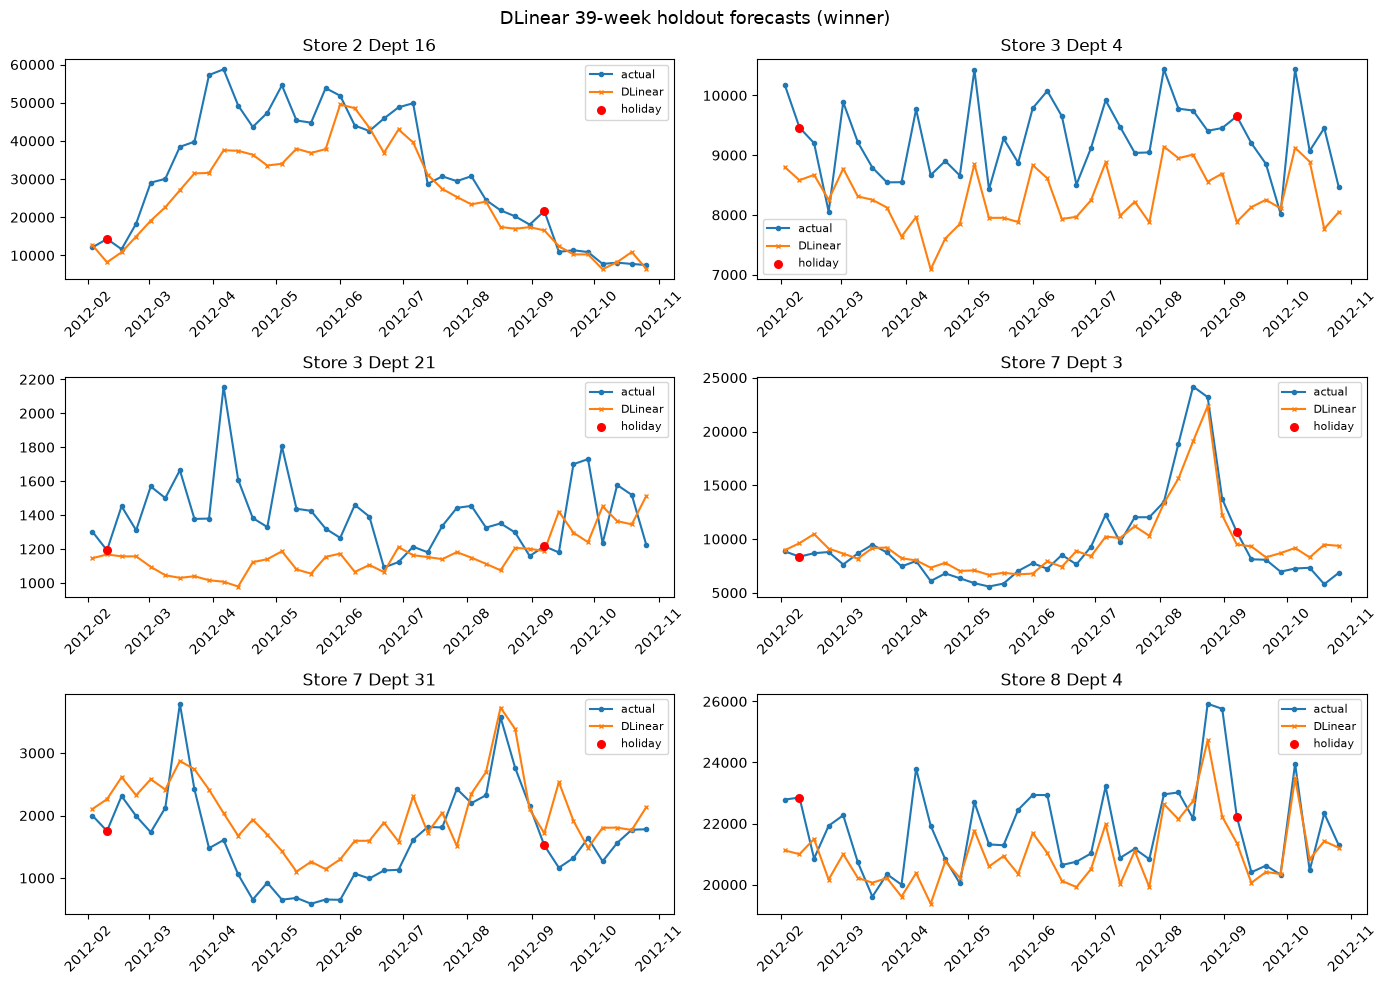

In [19]:
sample_series = holdout_only["pooled_holdout_predictions"].groupby(["Store", "Dept"])
keys_to_plot = list(sample_series.groups.keys())[:6]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, key in zip(axes.ravel(), keys_to_plot):
    g = sample_series.get_group(key).sort_values("Date")
    ax.plot(g["Date"], g["actual"], label="actual", marker="o", ms=3)
    ax.plot(g["Date"], g["prediction"], label="DLinear", marker="x", ms=3)
    holiday = g[g["IsHoliday"]]
    ax.scatter(holiday["Date"], holiday["actual"], color="red", zorder=5, s=30, label="holiday")
    ax.set_title(f"Store {key[0]} Dept {key[1]}")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

fig.suptitle("DLinear 39-week holdout forecasts (winner)", fontsize=13)
fig.tight_layout()
plt.show()